# preprocess image

[color detection](https://github.com/sakshigupta08/Color-Detector/blob/main/Color%20Detection.ipynb)

[feature extraction](https://doc.perclass.com/perClass_Toolbox/guide/feature_extraction/region.html#region:grid)

In [80]:
import os
import random
import cv2
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.svm import SVC

import imgaug as ia
import imgaug.augmenters as iaa
ia.seed(1)

# EDA

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Text(0.5, 1.0, 'cyn/image_08022023015555.jpg')

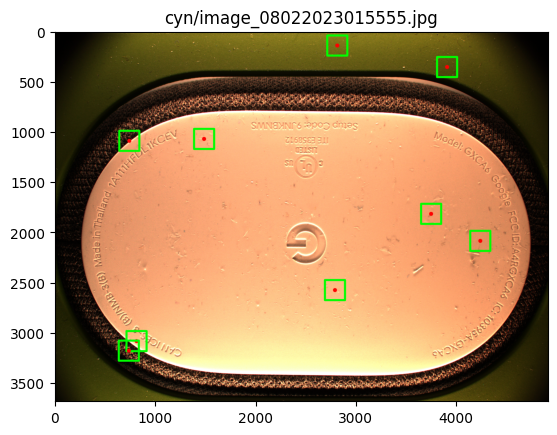

In [81]:
H = 3684 #pixel
W = 4912 #pixel
K = 100 #pixel
m = 3
N = m*m
dim = (W,H)
XMIN = DIM
YMIN = DIM
XMAX = W-DIM
YMAX = H-DIM
path = "cyn"
RED = (255,0,0)
GREEN = (0,255,0)
BLUE = (0,0,255)

# random reade images
imgs = os.listdir(path)
img = random.choice(imgs)
img_name = os.path.join(path,img)
img = cv2.imread(img_name)
img = img/255.0
img = cv2.resize(img,dim,interpolation=cv2.INTER_AREA)
img_org = img.copy()

# EDA 
X =  random.sample(range(XMIN,XMAX),N)
Y = random.sample(range(YMIN,YMAX),N)

# Extract rois
rois = []
for i in range(N):
    x=X[i]
    y=Y[i]
    rois.append(img_org[y-K:y+K,x-K:x+K])
    img = cv2.circle(img,(x,y),radius=20,color=RED,thickness=-1) # (x,y)
    img = cv2.rectangle(img,(x-K,y-K),(x+K,y+K),color=GREEN,thickness=20)

# Display image
plt.imshow(img)
plt.title(img_name)

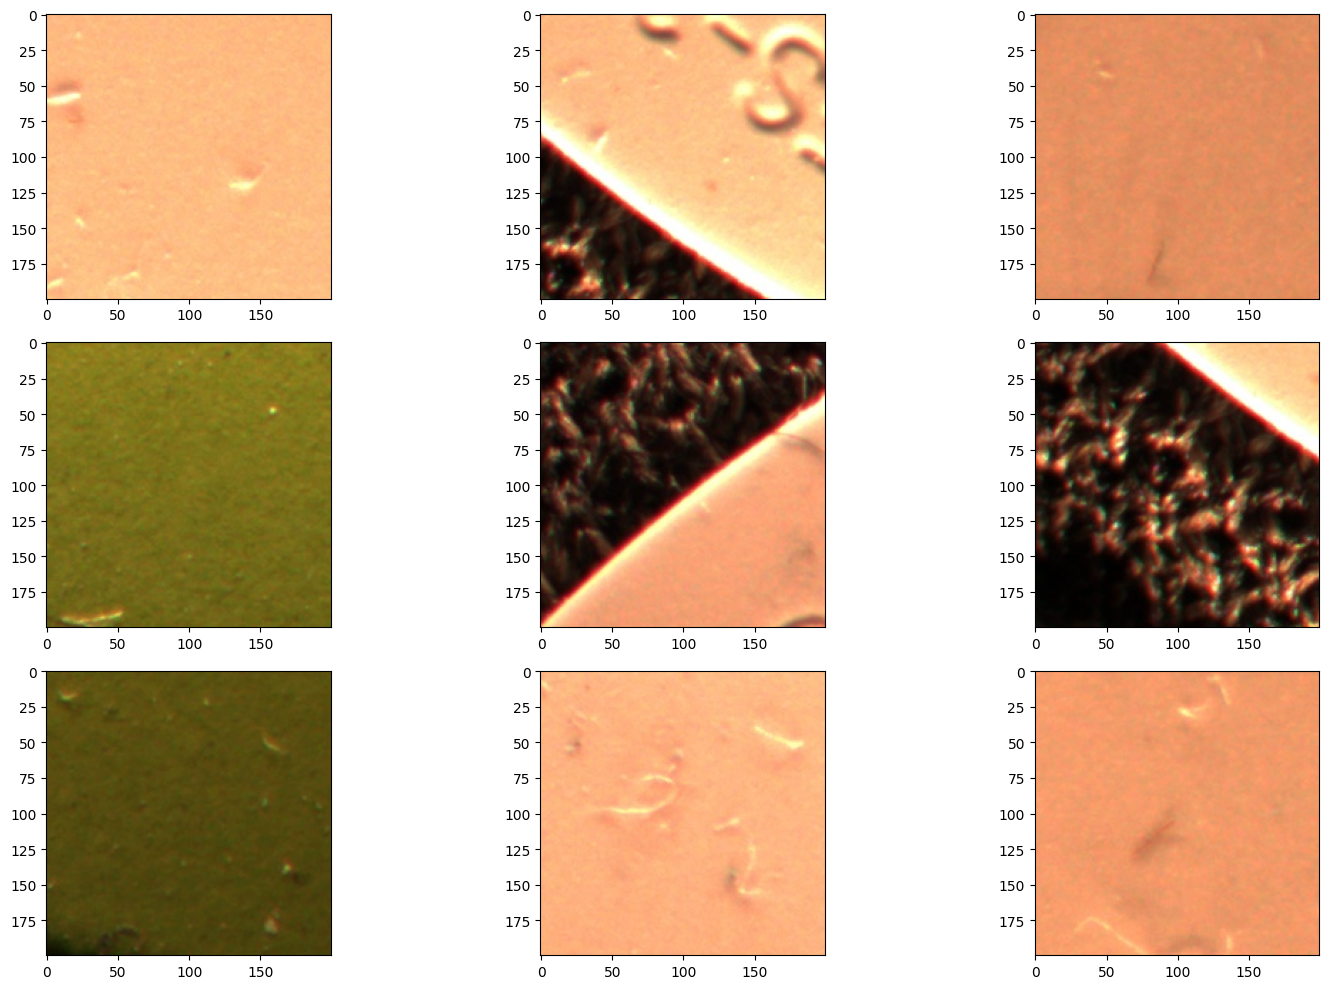

In [83]:
fig, axes = plt.subplots(nrows=m, ncols=m, figsize=(16,10))

for i in range(N):
    j = i//3
    k =  i%(3)
    axes[j][k].imshow(rois[i])
    
plt.tight_layout()

# defined mask